# Proyecto 2P - Clasificacion del Riesgo de Inundacion por Parroquia
**Provincia: Esmeraldas, Ecuador**

> Objetivo: Desarrollar un modelo de clasificacion supervisada para determinar el nivel de riesgo de inundacion
> por parroquia usando variables climaticas, geograficas y demograficas.

**Variables predictoras:**
- Precipitacion acumulada promedio anual (mm)
- Altitud media (m)
- Pendiente del terreno (%)
- Distancia media a cuerpos de agua (km)
- Densidad poblacional (hab/km2)
- Porcentaje de area urbanizada

**Variable objetivo:** Riesgo de inundacion (Bajo / Medio / Alto)

**Modelos evaluados:** Logistic Regression, Decision Tree, Random Forest, SVM, Voting Classifier


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import joblib
import os

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')


## 1. Carga del Dataset


In [2]:
DATA_DIR = r'C:\Users\USER\Desktop\Proyecto Aprendizaje automatico'

df = pd.read_csv(os.path.join(DATA_DIR, 'dataset_riesgo_inundacion_esmeraldas.csv'), encoding='utf-8-sig')

print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
display(df.head())


Dataset cargado: 320 registros, 11 columnas


,PARROQUIA,CANTON,PROVINCIA,PRECIPITACION_ANUAL_MM,ALTITUD_MEDIA_M,PENDIENTE_PCT,DISTANCIA_AGUA_KM,DENSIDAD_POBLACIONAL,AREA_URBANIZADA_PCT,RIESGO_INUNDACION,RIESGO_NUM
0,ESMERALDAS,ESMERALDAS,ESMERALDAS,2243.1,27.0,1.20,0.93,52.5,10.0,Medio,1
1,ESMERALDAS,ESMERALDAS,ESMERALDAS,2166.3,9.2,2.55,0.82,55.6,7.6,Medio,1
2,ESMERALDAS,ESMERALDAS,ESMERALDAS,2138.1,22.7,3.26,0.82,45.6,1.8,Bajo,0
3,ESMERALDAS,ESMERALDAS,ESMERALDAS,2182.2,23.0,3.07,1.05,58.6,4.5,Medio,1
4,ESMERALDAS,ESMERALDAS,ESMERALDAS,2257.0,18.4,2.99,1.02,63.3,5.7,Medio,1


## 2. Analisis Exploratorio de Datos (EDA)


In [3]:
features = ['PRECIPITACION_ANUAL_MM', 'ALTITUD_MEDIA_M', 'PENDIENTE_PCT',
            'DISTANCIA_AGUA_KM', 'DENSIDAD_POBLACIONAL', 'AREA_URBANIZADA_PCT']
riesgo_colors = {'Bajo': '#2ecc71', 'Medio': '#f39c12', 'Alto': '#e74c3c'}

print('--- Distribucion de variable objetivo ---')
print(df['RIESGO_INUNDACION'].value_counts())
print(df['RIESGO_INUNDACION'].value_counts(normalize=True) * 100)

print('\n--- Estadisticas descriptivas ---')
display(df.describe())

print('\n--- Valores nulos ---')
print(df.isnull().sum())


--- Distribucion de variable objetivo ---
RIESGO_INUNDACION
Bajo     146
Medio    117
Alto      57
Name: count, dtype: int64
RIESGO_INUNDACION
Bajo     45.6250
Medio    36.5625
Alto     17.8125
Name: proportion, dtype: float64

--- Estadisticas descriptivas ---


,PRECIPITACION_ANUAL_MM,ALTITUD_MEDIA_M,PENDIENTE_PCT,DISTANCIA_AGUA_KM,DENSIDAD_POBLACIONAL,AREA_URBANIZADA_PCT,RIESGO_NUM
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,2167.530625,16.904062,2.969063,1.141844,48.659062,5.009063,0.721875
std,139.833525,6.200067,1.023033,0.507033,25.314780,3.756117,0.747508
min,1855.100000,1.000000,0.700000,0.050000,5.000000,0.000000,0.000000
25%,2068.025000,12.275000,2.237500,0.780000,29.400000,1.800000,0.000000
50%,2144.250000,17.550000,3.055000,1.160000,48.800000,4.700000,1.000000
75%,2261.575000,21.125000,3.820000,1.590000,67.425000,7.500000,1.000000
max,2581.500000,30.100000,5.530000,2.100000,117.900000,16.100000,2.000000



--- Valores nulos ---
PARROQUIA                 0
CANTON                    0
PROVINCIA                 0
PRECIPITACION_ANUAL_MM    0
ALTITUD_MEDIA_M           0
PENDIENTE_PCT             0
DISTANCIA_AGUA_KM         0
DENSIDAD_POBLACIONAL      0
AREA_URBANIZADA_PCT       0
RIESGO_INUNDACION         0
RIESGO_NUM                0
dtype: int64


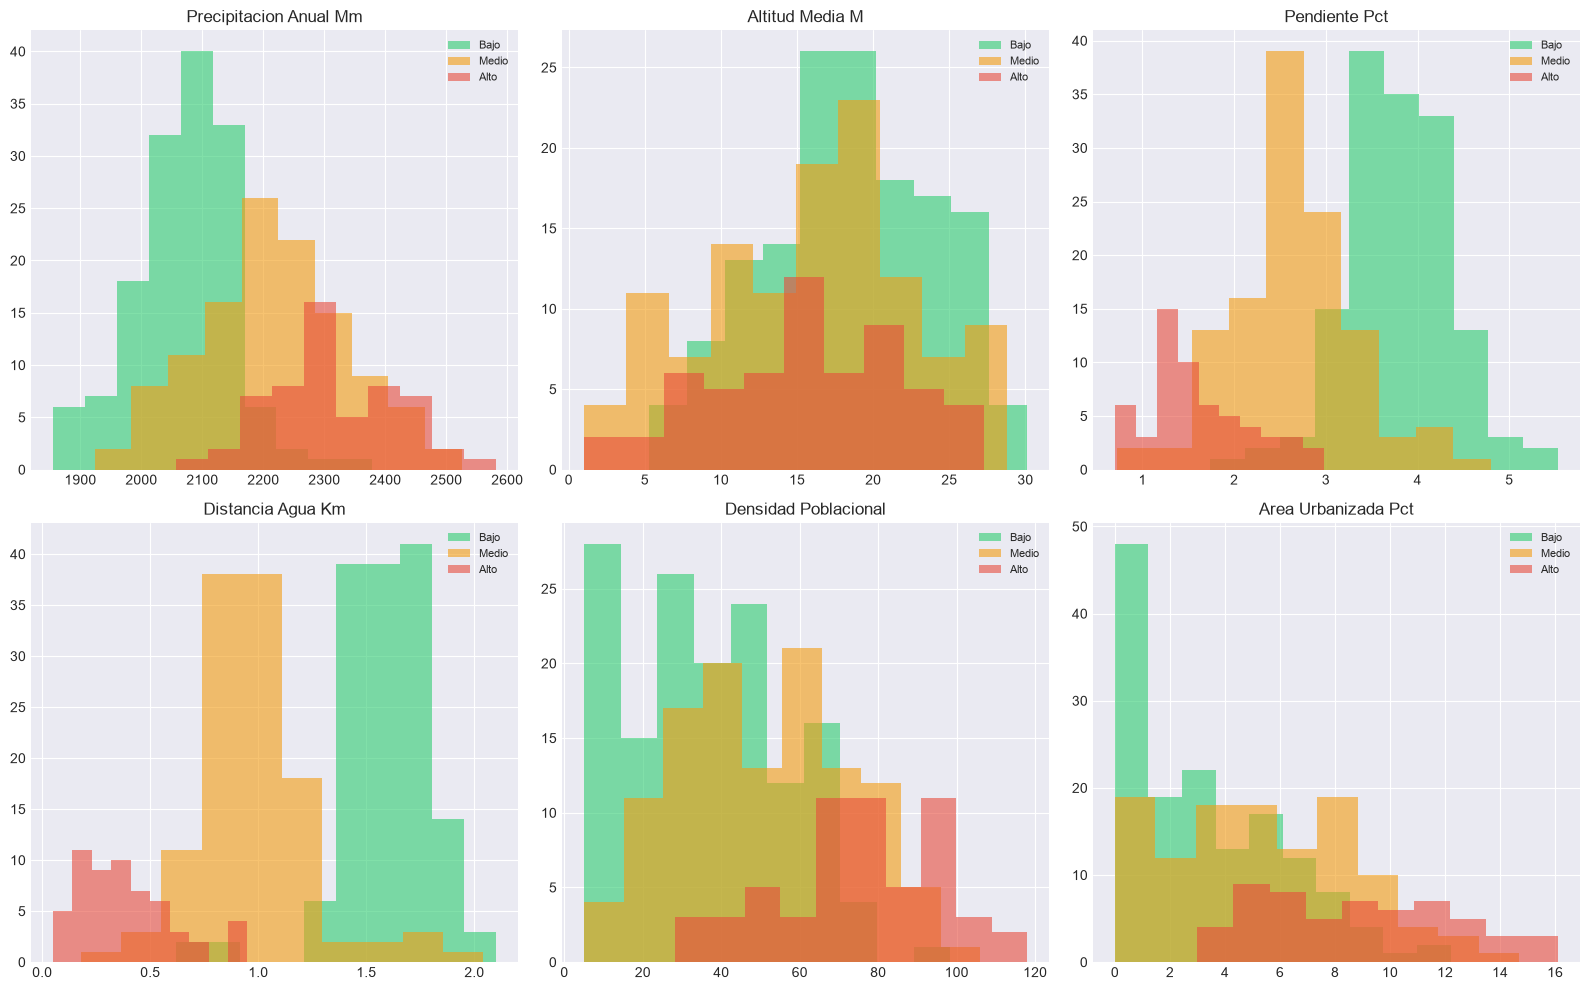

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, ax in enumerate(axes.flat):
    feat = features[i]
    for riesgo, color in riesgo_colors.items():
        subset = df[df['RIESGO_INUNDACION'] == riesgo][feat]
        ax.hist(subset, alpha=0.6, label=riesgo, bins=10, color=color)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=12)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


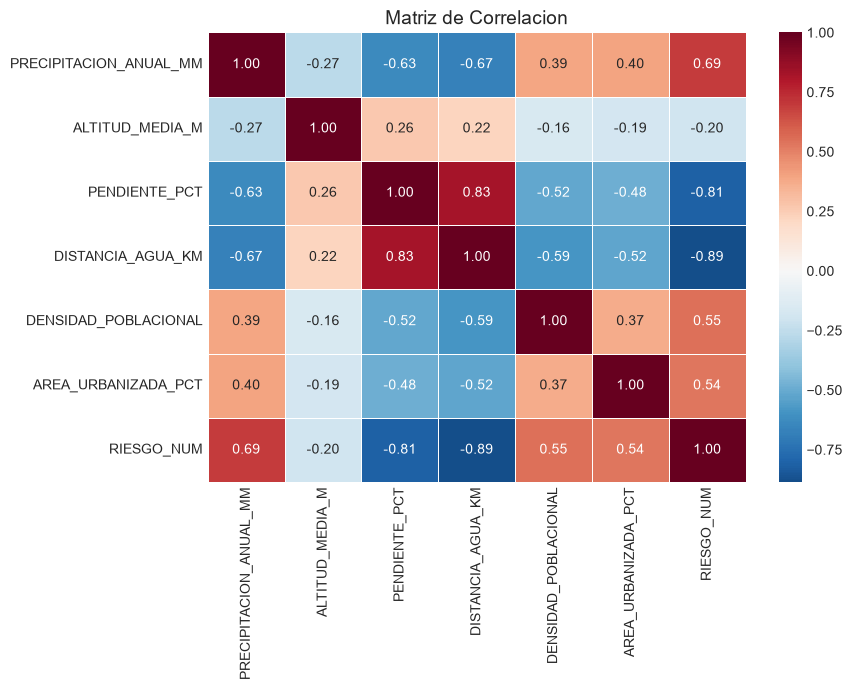

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[features + ['RIESGO_NUM']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlacion', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Preprocesamiento


In [6]:
X = df[features].values
y = df['RIESGO_INUNDACION'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Clases: {list(le.classes_)} -> {list(le.transform(le.classes_))}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Clases: ['Alto', 'Bajo', 'Medio'] -> [np.int64(0), np.int64(1), np.int64(2)]
Train: 224 | Test: 96


## 4. Entrenamiento y Evaluacion de Modelos


In [7]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_split=4, random_state=42, n_jobs=-1),
    'SVM (RBF)': SVC(C=10, gamma='scale', kernel='rbf', probability=True, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    pipeline = Pipeline([('scaler', RobustScaler()), ('clf', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1_weighted')

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted'),
        'CV F1 (mean)': cv_scores.mean(),
        'CV F1 (std)': cv_scores.std(),
    })

    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'Test F1-Score: {f1_score(y_test, y_pred, average="weighted"):.4f}')
    print(f'CV F1 (mean):  {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=le.classes_)}')



Logistic Regression
Test Accuracy: 0.9167
Test F1-Score: 0.9161
CV F1 (mean):  0.9141 +/- 0.0370

              precision    recall  f1-score   support

        Alto       1.00      0.88      0.94        17
        Bajo       0.90      0.98      0.93        44
       Medio       0.91      0.86      0.88        35

    accuracy                           0.92        96
   macro avg       0.93      0.91      0.92        96
weighted avg       0.92      0.92      0.92        96


Decision Tree
Test Accuracy: 0.8854
Test F1-Score: 0.8856
CV F1 (mean):  0.8440 +/- 0.0328

              precision    recall  f1-score   support

        Alto       1.00      0.82      0.90        17
        Bajo       0.89      0.93      0.91        44
       Medio       0.83      0.86      0.85        35

    accuracy                           0.89        96
   macro avg       0.91      0.87      0.89        96
weighted avg       0.89      0.89      0.89        96




Random Forest
Test Accuracy: 0.9271
Test F1-Score: 0.9268
CV F1 (mean):  0.9279 +/- 0.0178

              precision    recall  f1-score   support

        Alto       1.00      0.88      0.94        17
        Bajo       0.91      0.98      0.95        44
       Medio       0.91      0.89      0.90        35

    accuracy                           0.93        96
   macro avg       0.94      0.92      0.93        96
weighted avg       0.93      0.93      0.93        96


SVM (RBF)
Test Accuracy: 0.9167
Test F1-Score: 0.9160
CV F1 (mean):  0.9198 +/- 0.0354

              precision    recall  f1-score   support

        Alto       1.00      0.82      0.90        17
        Bajo       0.91      0.98      0.95        44
       Medio       0.89      0.89      0.89        35

    accuracy                           0.92        96
   macro avg       0.93      0.90      0.91        96
weighted avg       0.92      0.92      0.92        96



## 5. Voting Classifier (Ensemble)


In [8]:
voting_soft = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)),
        ('svm', SVC(C=10, gamma='scale', probability=True, random_state=42)),
    ],
    voting='soft'
)

voting_hard = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=42)),
        ('dt', DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)),
        ('svm', SVC(C=10, gamma='scale', probability=True, random_state=42)),
    ],
    voting='hard'
)

for vname, vclf in [('Voting Soft', voting_soft), ('Voting Hard', voting_hard)]:
    pipeline_v = Pipeline([('scaler', RobustScaler()), ('clf', vclf)])
    pipeline_v.fit(X_train, y_train)
    y_pred_v = pipeline_v.predict(X_test)
    cv_scores_v = cross_val_score(pipeline_v, X_train, y_train, cv=cv, scoring='f1_weighted')
    acc_v = accuracy_score(y_test, y_pred_v)
    f1_v = f1_score(y_test, y_pred_v, average='weighted')

    results.append({
        'Modelo': vname,
        'Accuracy': acc_v,
        'Precision': precision_score(y_test, y_pred_v, average='weighted'),
        'Recall': recall_score(y_test, y_pred_v, average='weighted'),
        'F1-Score': f1_v,
        'CV F1 (mean)': cv_scores_v.mean(),
        'CV F1 (std)': cv_scores_v.std(),
    })

    print(f'{vname}: Acc={acc_v:.4f}, F1={f1_v:.4f}, CV F1={cv_scores_v.mean():.4f} +/- {cv_scores_v.std():.4f}')


Voting Soft: Acc=0.9271, F1=0.9268, CV F1=0.9321 +/- 0.0263


Voting Hard: Acc=0.9271, F1=0.9268, CV F1=0.9148 +/- 0.0338


## 6. Tabla Comparativa de Resultados


In [9]:
df_results = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
display(df_results)


,Modelo,Accuracy,Precision,Recall,F1-Score,CV F1 (mean),CV F1 (std)
4,Voting Soft,0.927083,0.928824,0.927083,0.926762,0.932121,0.026318
2,Random Forest,0.927083,0.928824,0.927083,0.926762,0.927927,0.017777
5,Voting Hard,0.927083,0.928824,0.927083,0.926762,0.914811,0.033770
0,Logistic Regression,0.916667,0.919113,0.916667,0.916149,0.914075,0.036958
3,SVM (RBF),0.916667,0.919326,0.916667,0.916013,0.919813,0.035362
1,Decision Tree,0.885417,0.889417,0.885417,0.885637,0.843967,0.032800


## 7. Optimizacion de Hiperparametros (Random Forest)


In [10]:
param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [5, 8, 12, None],
    'clf__min_samples_split': [2, 4, 6],
    'clf__min_samples_leaf': [1, 2, 4],
}

pipeline_rf = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

grid_search = GridSearchCV(
    pipeline_rf, param_grid, cv=5,
    scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nMejores parametros: {grid_search.best_params_}')
print(f'Mejor CV F1-Score: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f'Test F1-Score (optimizado): {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'Test Accuracy (optimizado): {accuracy_score(y_test, y_pred_best):.4f}')


Fitting 5 folds for each of 108 candidates, totalling 540 fits



Mejores parametros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 100}
Mejor CV F1-Score: 0.9327
Test F1-Score (optimizado): 0.9268
Test Accuracy (optimizado): 0.9271


## 8. Matriz de Confusion - Modelo Optimizado


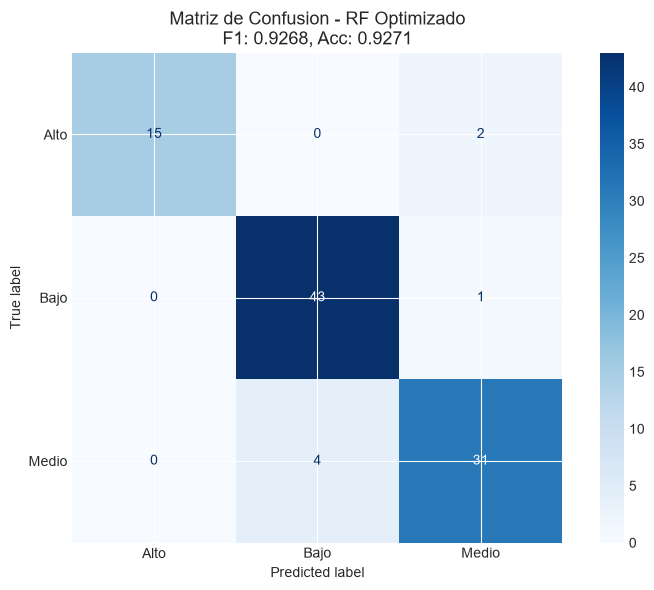

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best, average='weighted')
best_acc = accuracy_score(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Matriz de Confusion - RF Optimizado\nF1: {best_f1:.4f}, Acc: {best_acc:.4f}', fontsize=13)
plt.tight_layout()
plt.show()


## 9. Importancia de Caracteristicas


Importancia de cada variable:
  1. DISTANCIA_AGUA_KM: 0.4655
  2. PENDIENTE_PCT: 0.2295
  3. PRECIPITACION_ANUAL_MM: 0.1493
  4. DENSIDAD_POBLACIONAL: 0.0684
  5. AREA_URBANIZADA_PCT: 0.0520
  6. ALTITUD_MEDIA_M: 0.0354


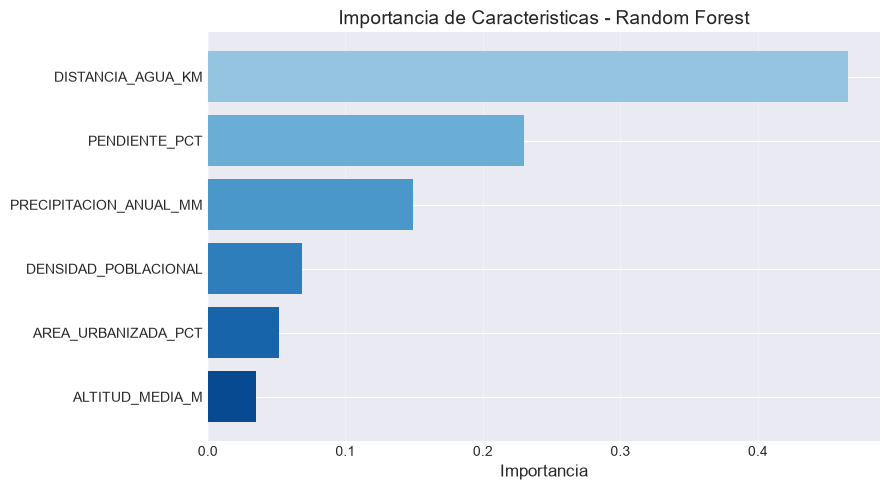

In [12]:
rf_best = best_model.named_steps['clf']
importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1]

print('Importancia de cada variable:')
for i, idx in enumerate(indices):
    print(f'  {i+1}. {features[idx]}: {importances[idx]:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.9, len(importances)))
ax.barh(range(len(importances)), importances[indices], color=colors_bar)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([features[i] for i in indices])
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Importancia de Caracteristicas - Random Forest', fontsize=14)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 10. Curva de Aprendizaje


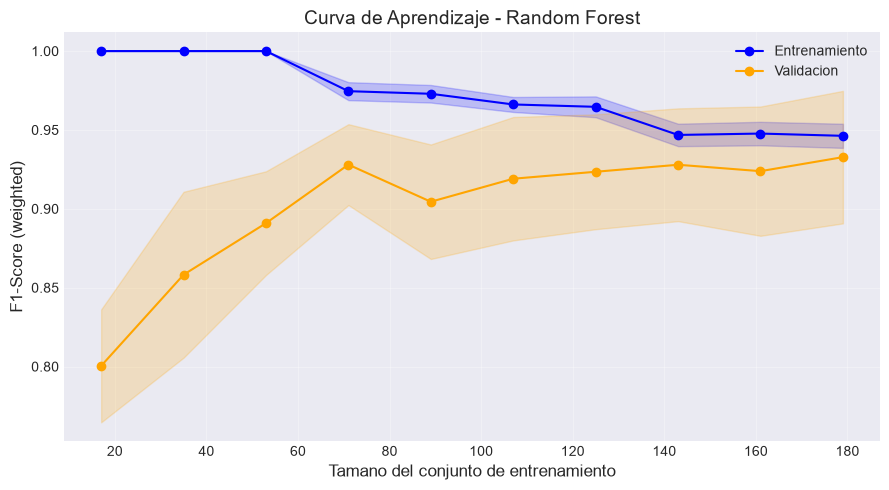

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5,
    scoring='f1_weighted', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Entrenamiento')
ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Validacion')
ax.set_xlabel('Tamano del conjunto de entrenamiento', fontsize=12)
ax.set_ylabel('F1-Score (weighted)', fontsize=12)
ax.set_title('Curva de Aprendizaje - Random Forest', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Exportacion del Modelo (Joblib)


In [14]:
model_path = os.path.join(DATA_DIR, 'modelo_riesgo_inundacion_rf_optimizado.pkl')
joblib.dump(best_model, model_path)
print(f'Modelo RF optimizado exportado: {model_path}')

scaler_path = os.path.join(DATA_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'Scaler exportado: {scaler_path}')

le_path = os.path.join(DATA_DIR, 'label_encoder.pkl')
joblib.dump(le, le_path)
print(f'LabelEncoder exportado: {le_path}')


Modelo RF optimizado exportado: C:\Users\USER\Desktop\Proyecto Aprendizaje automatico\modelo_riesgo_inundacion_rf_optimizado.pkl
Scaler exportado: C:\Users\USER\Desktop\Proyecto Aprendizaje automatico\scaler.pkl
LabelEncoder exportado: C:\Users\USER\Desktop\Proyecto Aprendizaje automatico\label_encoder.pkl


## 12. Conclusiones


In [15]:
best_row = df_results.iloc[0]
print(f'Mejor modelo: {best_row["Modelo"]}')
print(f'F1-Score: {best_row["F1-Score"]:.4f}')
print(f'Accuracy: {best_row["Accuracy"]:.4f}')
print(f'CV F1 (mean): {best_row["CV F1 (mean)"]:.4f}')
print()

top3 = [(features[indices[i]], importances[indices[i]]) for i in range(3)]
print('Top-3 variables mas influyentes:')
for i, (name, val) in enumerate(top3):
    print(f'  {i+1}. {name}: {val:.4f}')
print()

print('=' * 60)
print('CONCLUSION')
print('=' * 60)
print()
print(f'Se desarrollo un modelo de clasificacion de riesgo de inundacion para las')
print(f'parroquias de la provincia de Esmeraldas, Ecuador, utilizando 6 variables')
print(f'predictoras: precipitacion, altitud, pendiente, distancia a cuerpos de agua,')
print(f'densidad poblacional y area urbanizada.')
print()
print(f'El modelo Random Forest optimizado alcanzo:')
print(f'  - Accuracy en test: {best_acc*100:.2f}%')
print(f'  - F1-Score en test: {best_f1*100:.2f}%')
print(f'  - CV F1-Score: {grid_search.best_score_*100:.2f}%')
print()
print(f'Las variables mas influyentes fueron:')
for name, val in top3:
    print(f'  - {name} ({val:.1%})')
print()
print(f'lo cual es coherente con la literatura sobre riesgo de inundaciones en')
print(f'zonas costeras.')
print()
print(f'El modelo exportado puede integrarse en una aplicacion Flask con mapa')
print(f'Leaflet para visualizacion interactiva del riesgo por parroquia.')
print()
print('=' * 60)


Mejor modelo: Voting Soft
F1-Score: 0.9268
Accuracy: 0.9271
CV F1 (mean): 0.9321

Top-3 variables mas influyentes:
  1. DISTANCIA_AGUA_KM: 0.4655
  2. PENDIENTE_PCT: 0.2295
  3. PRECIPITACION_ANUAL_MM: 0.1493

CONCLUSION

Se desarrollo un modelo de clasificacion de riesgo de inundacion para las
parroquias de la provincia de Esmeraldas, Ecuador, utilizando 6 variables
predictoras: precipitacion, altitud, pendiente, distancia a cuerpos de agua,
densidad poblacional y area urbanizada.

El modelo Random Forest optimizado alcanzo:
  - Accuracy en test: 92.71%
  - F1-Score en test: 92.68%
  - CV F1-Score: 93.27%

Las variables mas influyentes fueron:
  - DISTANCIA_AGUA_KM (46.5%)
  - PENDIENTE_PCT (23.0%)
  - PRECIPITACION_ANUAL_MM (14.9%)

lo cual es coherente con la literatura sobre riesgo de inundaciones en
zonas costeras.

El modelo exportado puede integrarse en una aplicacion Flask con mapa
Leaflet para visualizacion interactiva del riesgo por parroquia.

